# 🖼️ MDIF: A Multi-Domain Inconsistency Framework for Image Forgery Detection


## Imports

In [1]:
from pathlib import Path

from mdif.preprocessing.compute_features import process_dataset_with_split
from mdif.training.train_spatial import train as train_spatial
from mdif.training.train_fusion import train as train_fusion

from mdif.evaluate import evaluate

from mdif.inference import infer


Using cache found in C:\Users\joecn/.cache\torch\hub\intel-isl_MiDaS_master
d:\ProgramData\miniconda3\envs\mdif\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in C:\Users\joecn/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\joecn/.cache\torch\hub\intel-isl_MiDaS_master
Using cache found in C:\Users\joecn/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Loading weights:  None


---

## Preprocessing Images


In [ ]:
BASE_RAW = Path("../data/raw")
BASE_PROC = Path("../data/processed")

# CIFAKE has its own test/train folders, so we process them separately with ratio 1.0
process_dataset_with_split(
    BASE_RAW / "CIFAKE/train", BASE_PROC, {"REAL": 0, "FAKE": 1}, split_ratio=1.0
)
process_dataset_with_split(
    BASE_RAW / "CIFAKE/test", BASE_PROC, {"REAL": 0, "FAKE": 1}, split_ratio=0.0
)

# AutoSplice is often one big folder, so we split it 80/20
process_dataset_with_split(
    BASE_RAW / "AutoSplice",
    BASE_PROC,
    {"Authentic": 0, "Forged_JPEG90": 2},
    split_ratio=0.8,
)

# CocoGlide split
process_dataset_with_split(
    BASE_RAW / "CocoGlide", BASE_PROC, {"real": 0, "fake": 2}, split_ratio=0.8
)

# GenImage split
process_dataset_with_split(
    BASE_RAW / "GenImage",
    BASE_PROC,
    {"Nature": 0, "Midjourney": 1, "glide": 1},
    split_ratio=0.8,
)


---

## Training Spatial Model


In [5]:
train_spatial()


Starting Spatial Training on: cuda


Epoch 1/15: 100%|██████████| 1428/1428 [09:51<00:00,  2.42it/s, Loss=0.0763]


Epoch 1: Train Acc: 92.64%, Val Acc: 93.86%
--- Best Model Saved ---


Epoch 2/15: 100%|██████████| 1428/1428 [06:42<00:00,  3.55it/s, Loss=0.1050]


Epoch 2: Train Acc: 96.59%, Val Acc: 94.91%
--- Best Model Saved ---


...

Epoch 13: Train Acc: 99.66%, Val Acc: 96.63%
--- Best Model Saved ---


Epoch 14/15: 100%|██████████| 1428/1428 [02:50<00:00,  8.39it/s, Loss=0.0029]


Epoch 14: Train Acc: 99.70%, Val Acc: 96.72%
--- Best Model Saved ---


Epoch 15/15: 100%|██████████| 1428/1428 [02:49<00:00,  8.40it/s, Loss=0.0097]


Epoch 15: Train Acc: 99.68%, Val Acc: 96.69%


---

## Training Fusion Model


In [6]:
train_fusion()


Starting Fusion Training on: cuda


Epoch 1/20 [Train]: 100%|██████████| 1428/1428 [02:38<00:00,  9.03it/s, Loss=0.1957]


Epoch 1: T-Loss: 0.5793, T-Acc: 92.38%, V-Loss: 0.1057, V-Acc: 93.08%
--- Best Model Saved (Acc: 93.08%) ---


Epoch 2/20 [Train]: 100%|██████████| 1428/1428 [02:35<00:00,  9.17it/s, Loss=0.1536]


Epoch 2: T-Loss: 0.0962, T-Acc: 96.52%, V-Loss: 0.0676, V-Acc: 97.73%
--- Best Model Saved (Acc: 97.73%) ---


...

Epoch 18: T-Loss: 0.0483, T-Acc: 98.44%, V-Loss: 0.0541, V-Acc: 98.17%


Epoch 19/20 [Train]: 100%|██████████| 1428/1428 [04:49<00:00,  4.94it/s, Loss=0.0355]


Epoch 19: T-Loss: 0.0466, T-Acc: 98.49%, V-Loss: 0.0508, V-Acc: 98.04%


Epoch 20/20 [Train]: 100%|██████████| 1428/1428 [03:46<00:00,  6.29it/s, Loss=0.0021]


Epoch 20: T-Loss: 0.0504, T-Acc: 98.39%, V-Loss: 0.1019, V-Acc: 96.72%


---

## Evaluating Model

Evaluating 23552 images...


100%|██████████| 736/736 [04:53<00:00,  2.50it/s]


[RESULTS]
Overall Accuracy: 96.36%
Target AUC-ROC (>0.93): 0.9958

Detailed Classification Report:
              precision    recall  f1-score   support

   Authentic       0.97      0.96      0.96     11724
   Generated       0.97      0.98      0.97     11000
   Inpainted       0.76      0.89      0.82       828

    accuracy                           0.96     23552
   macro avg       0.90      0.94      0.92     23552
weighted avg       0.96      0.96      0.96     23552



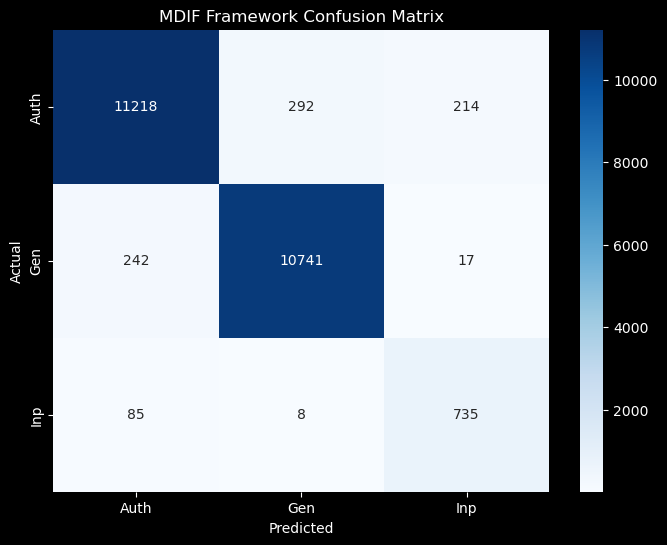

In [2]:
evaluate()


---

## Predicting

--- MDIF Image Forgery Detector ---


Predicting for: real_flower2.jpg


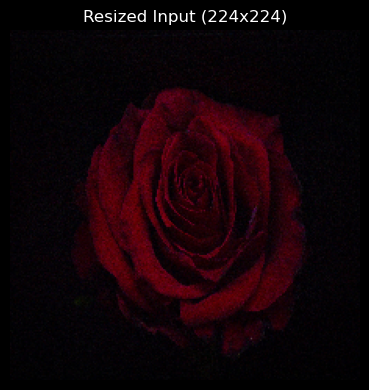


Result: Authentic Photograph
Confidence: 100.00%

Scores:
- Authentic Photograph: 100.00%
- Fully AI-Generated: 0.00%
- Partially AI-Inpainted: 0.00%


Predicting for: gen_nanoban_flower.jpg


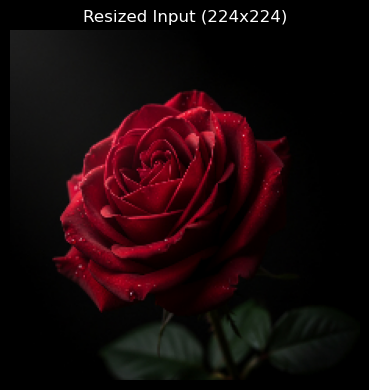


Result: Fully AI-Generated
Confidence: 99.99%

Scores:
- Authentic Photograph: 0.01%
- Fully AI-Generated: 99.99%
- Partially AI-Inpainted: 0.00%


In [5]:
infer()
